# Download data from Google Earth Engine
This code snippet provides an example of accessing and downloading data from Google Earth Engine using the earthengine-api for Python (read the [docs](https://developers.google.com/earth-engine/tutorials/community/intro-to-python-api)).

You will first need to register for a (free) Google Cloud project account.

In this snippet, we will download data from Sentinel-2. You can browse the available datasets in the [Earth Engine Catalog](https://developers.google.com/earth-engine/datasets/catalog). There is also the [awesome-gee-community-catalog](https://gee-community-catalog.org/projects/) providing additional datasets contributed by the open-source community.

## Setup

In [1]:
# Install earthengine-api
# !pip install earthengine-api
# !pip install geemap
!pip install geedim
!pip install --upgrade --pre xee

  Using cached geedim-2.0.0-py3-none-any.whl.metadata (6.0 kB)
Using cached geedim-2.0.0-py3-none-any.whl (73 kB)
  Using cached xee-0.1.1-py3-none-any.whl.metadata (4.8 kB)
Using cached xee-0.1.1-py3-none-any.whl (35 kB)


In [2]:
from pathlib import Path
import ee
import geemap
import xee
from xee import helpers
import xarray as xr
from shapely import box
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
# Trigger the authentication flow
ee.Authenticate()

# Initialize the library
# You will need to follow the link, then copy and paste the verification code
ee.Initialize() #project='my-project'

exo-open: Cannot open display: .


Enter verification code:  4/1AdkVLPxQYd3SL8MykfcDBmfcFkp3e22_gDXQw8FVj7Jc9kkGigo86Be-flQ



Successfully saved authorization token.


## Data search

Here is where you'll **update using your own search parameters:**
* The sensor / product name: known in Google Earth Engine as the **image collection** (`ee.ImageCollection`)
* The region: here defined using a **bounding box**
* The time period: here defined using a **start and end date**
* Count: max number of images to return.

Visit the data catalog to determine the bands you want. Example for Sentinel-2: https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S2_SR_HARMONIZED#bands

In [4]:
# Define collection
collection_name = 'COPERNICUS/S2_SR_HARMONIZED'

# Define bands to select fromm the collection
bands = ['B1','B2','B3','B4','B5','B6','B7','B8A','B11','B12']

# Define start and end dates for search
start_date, end_date = '2019-05-01', '2019-05-10'  

# Define max number of images to return
count = 100

# Define region of interest (roi) using bounding box geometry
region = box(-97.7, 42.8, -97.5, 43.0)

In [5]:
# Convert the region to ee feature collection
region_gdf = gpd.GeoDataFrame(geometry=[region], crs=4326)
region_geometry = geemap.geopandas_to_ee(region_gdf).geometry()

print(f"Searching collection {collection_name} between {start_date} and {end_date} for region {region.bounds}.")

# Filter the image collection for the region and dates
collection = ee.ImageCollection(collection_name)\
                .filterDate(start_date, end_date)\
                .filterBounds(region_geometry)\
                .limit(count)
               #.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE',20))\ # optionally filter by cloud pixel pct band for S2
                
# Print the number of images retured
collection_size = collection.size().getInfo()
print(f"Search returned {collection_size} images:")

# Get image IDs of images in the collection
image_ids = [f'{collection_name}/{im_id}' for im_id in collection.aggregate_array('system:index').getInfo()]
print(image_ids)

# Show the collection
collection

Searching collection COPERNICUS/S2_SR_HARMONIZED between 2019-05-01 and 2019-05-10 for region (-97.7, 42.8, -97.5, 43.0).
Search returned 4 images:
['COPERNICUS/S2_SR_HARMONIZED/20190503T171901_20190503T172731_T14TNN', 'COPERNICUS/S2_SR_HARMONIZED/20190503T171901_20190503T172731_T14TPN', 'COPERNICUS/S2_SR_HARMONIZED/20190508T171909_20190508T173011_T14TNN', 'COPERNICUS/S2_SR_HARMONIZED/20190508T171909_20190508T173011_T14TPN']


## Open or download data

You have the option to either stream the data into Python or download the data. 

In both cases, you will first need to specify the files from your search that you want to download. You can either download all of them, or choose specific files from the list we just got.

### Data streaming

To stream our filtered collection from Google Earth Engine directly into Python, we'll use the [xee library](https://github.com/google/Xee).

In [6]:
grid = helpers.extract_grid_params(collection)
print(grid)

# Load the collection into a xr dataset
dataset = xr.open_dataset(collection.select(bands), engine='ee', **grid)

# Convert the datset with bands as separate variables into a single data array with band dimension
# This step may take some time to run
data = dataset.to_array(dim="band").rio.write_crs(grid['crs'])
print(f'Loaded data with shape: {data.shape}')
data

{'crs': 'EPSG:32614', 'crs_transform': (60, 0, 499980, 0, -60, 4800000), 'shape_2d': (1830, 1830)}
Loaded data with shape: (10, 4, 1830, 1830)


<xarray.DataArray (band: 10, time: 4, y: 1830, x: 1830)> Size: 536MB
array([[[[10226., 11395., 11197., ...,   699.,   697.,   524.],
         [11644., 12990., 12787., ...,   895.,   921.,   661.],
         [11775., 13062., 12986., ...,   770.,   869.,   638.],
         ...,
         [ 1052.,  1263.,  1210., ..., 15848., 16000., 14354.],
         [  954.,  1169.,  1163., ..., 16086., 16245., 14571.],
         [  761.,   918.,   906., ..., 14483., 14644., 13126.]],

        [[   nan,    nan,    nan, ...,   643.,   587.,   594.],
         [   nan,    nan,    nan, ...,   866.,   846.,   852.],
         [   nan,    nan,    nan, ...,   726.,   788.,   814.],
         ...,
         [   nan,    nan,    nan, ..., 16886., 16808., 16719.],
         [   nan,    nan,    nan, ..., 17139., 17070., 16966.],
         [   nan,    nan,    nan, ..., 15431., 15386., 15307.]],

        [[ 8494.,  8948.,  8871., ...,  9141.,  9237.,  8633.],
         [ 8927.,  9512.,  9399., ...,  9851., 10008.,  9244.],
         [ 8810.,  9347.,  9222., ...,  9708.,  9862.,  9152.],
         ...,
...
         [   nan,    nan,    nan, ...,  2941.,  2959.,  2954.],
         [   nan,    nan,    nan, ...,  2924.,  2929.,  2943.],
         [   nan,    nan,    nan, ...,  2954.,  2931.,  2947.]],

        [[ 1866.,  1878.,  1869., ...,  2858.,  2860.,  2876.],
         [ 1871.,  1871.,  1838., ...,  2868.,  2882.,  2896.],
         [ 1890.,  1879.,  1860., ...,  2867.,  2869.,  2900.],
         ...,
         [ 2030.,  2031.,  2032., ...,  1859.,  1864.,  1847.],
         [ 2043.,  2077.,  2063., ...,  1835.,  1849.,  1818.],
         [ 2078.,  2078.,  2063., ...,  1829.,  1811.,  1812.]],

        [[   nan,    nan,    nan, ...,  2851.,  2871.,  2889.],
         [   nan,    nan,    nan, ...,  2873.,  2906.,  2908.],
         [   nan,    nan,    nan, ...,  2881.,  2891.,  2910.],
         ...,
         [   nan,    nan,    nan, ...,  1833.,  1873.,  1867.],
         [   nan,    nan,    nan, ...,  1827.,  1865.,  1841.],
         [   nan,    nan,    nan, ...,  1852.,  1813.,  1816.]]]],
      dtype=float32)
Coordinates:
  * band         (band) object 80B 'B1' 'B2' 'B3' 'B4' ... 'B8A' 'B11' 'B12'
  * time         (time) datetime64[ns] 32B 2019-05-03T17:32:04.313000 ... 201...
  * y            (y) float64 15kB 4.8e+06 4.8e+06 4.8e+06 ... 4.69e+06 4.69e+06
  * x            (x) float64 15kB 5e+05 5.001e+05 ... 6.097e+05 6.098e+05
    spatial_ref  int64 8B 0
Attributes: (12/17)
    date_range:             [1490659200000, 1647907200000]
    description:            <p>Sentinel-2 is a wide-swath, high-resolution, m...
    keywords:               ['copernicus', 'esa', 'eu', 'msi', 'reflectance',...
    period:                 0
    product_tags:           ['msi', 'sr', 'reflectance']
    provider:               European Union/ESA/Copernicus
    ...                     ...
    title:                  Sentinel-2 MSI: MultiSpectral Instrument, Level-2A
    type_name:              ImageCollection
    visualization_0_bands:  B4,B3,B2
    visualization_0_max:    3000.0
    visualization_0_min:    0.0
    visualization_0_name:   RGB

<Axes: title={'center': 'time = 2019-05-03T17:32:04.313000, spatial_ref = 0'}, xlabel='x', ylabel='y'>

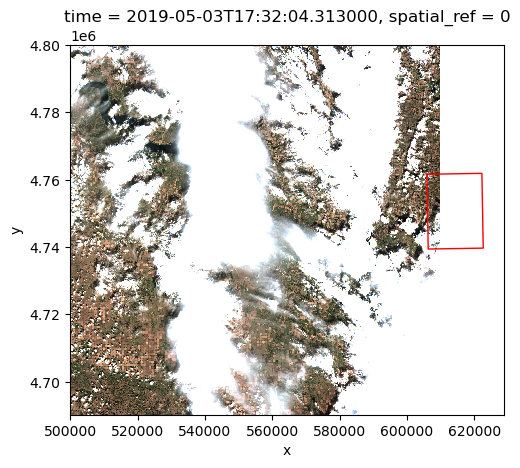

In [11]:
# Quick basic RGB plot for the first image in the image collection

# Get RGB data cube, linear stretch normalized
rgb = data.sel(band=['B4', 'B3', 'B2'])
rgb = (rgb / 3000).clip(0, 1)

# RGB plot
rgb.isel(time=0).plot.imshow()
region_gdf.to_crs(rgb.rio.crs).plot(ax=plt.gca(), facecolor='none', edgecolor='r')

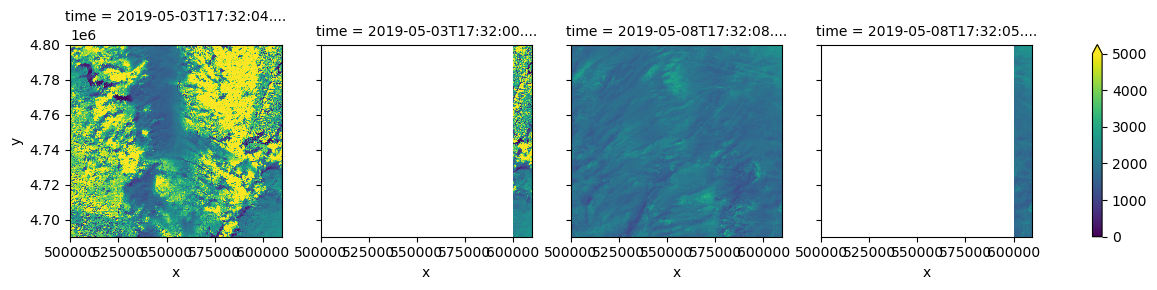

In [12]:
# SWIR band plot all timestamps
swir = data.sel(band='B11')
swir.plot(col='time', vmin=0, vmax=5000)

### Data download

There are a few different ways to download data from GEE. You could for example use the xr.DataArray we loaded using xee and write that out to GeoTIFF or NetCDF. A lot of researchers use geemap methods to download data directly from GEE: https://book.geemap.org/chapters/07_data_export.html

In [13]:
# Get an image for the first image in our returned collection, select RGB bands for visualizing
image_to_viz = ee.Image(image_ids[0]).select(['B4', 'B3', 'B2'])

# Lets do a qucik interative map through geemap
Map = geemap.Map()

vis_params = {'min': 0, 'max': 3000, 'gamma': [0.95, 1.1, 1]}

Map.centerObject(image_to_viz, 9)
Map.addLayer(image_to_viz, vis_params, 'Sentinel-2')
Map.addLayer(region_geometry, {'color': 'FF0000'}, ' Region')
Map

Map(center=[42.85657217597929, -98.32840742763739], controls=(WidgetControl(options=['position', 'transparent_…

### Download

In [14]:
# Define path to download to
downloadPath = Path('data/downloads/GEE_Sentinel2') # MODIFY
downloadPath.mkdir(exist_ok=True, parents=True) # Create download directory if does not already exist

In [15]:
# Download image using geemap

# Download the first image in our collection for the bands we specified earlier
# Or if you want to download every image in the collection
# swap out [image_ids[0]] for image_ids if you want to download all images
for image_id in [image_ids[0]]: # MODIFY 

    # Get the image to download and select the bands to download
    image_to_download = ee.Image(image_id).select(bands)

    # Create image name
    image_name = image_to_download.get('system:index').getInfo()

    # Get image CRS and scale
    # image_crs, image_scale = grid['crs'], grid['crs_transform'][0]
    image_proj = image_to_download.select('B1').projection().getInfo()
    image_crs, image_scale = image_proj['crs'], image_proj['transform'][0]
    print(f'Downloading {image_name} in CRS {image_crs} at scale {image_scale}')
    
    # Export
    geemap.ee_export_image(image_to_download, filename=str(downloadPath/f'{image_name}.tif'), 
                           scale=image_scale, region=region_geometry, file_per_band=False)

Generating URL ...
Please wait ...
Data downloaded to /home/jovyan/Projects/2026-Coding-Alex/snippets/data/downloads/GEE_Sentinel2/20190503T171901_20190503T172731_T14TNN.tif


In [ ]:
# # Can't get geemap.download_ee_image to run on cryocloud notebook
# geemap.download_ee_image(image_to_download, str(downloadPath/f'{image_name}.tif'), 
#                          scale=image_scale, crs=image_crs, region=region_geometry)

# # Download using geemap fishnet to download in smaller tiles
# # Use this option if trying to download a large size area with many pixels
# gridFeatures = geemap.fishnet(geom, rows=nrows, cols=ncols)
# geemap.download_ee_image_tiles(image_to_download, gridFeatures, 
#                                str(downloadPath), prefix=f'{image_name}_', 
#                                scale=image_scale, crs=image_crs)